### cell below install condacolab if you don't use colab to run this code ignore it

In [1]:
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:07
🔁 Restarting kernel...


## install Requirements and our model

In [1]:

!pip install ninja yacs cython matplotlib tqdm opencv-python overrides gpustat gitpython ipdb graphviz tensorboardx termcolor scikit-learn parse packaging h5py ipykernel
!pip install numpy==1.24.1
!conda install pytorch==2.1.0 torchvision==0.16.0 torchaudio==2.1.0 pytorch-cuda=12.1 -c pytorch -c nvidia
%cd /content/
!git clone https://github.com/cocodataset/cocoapi.git
%cd cocoapi/PythonAPI
!python setup.py build_ext install

# Clone and install apex
%cd /content/
!git clone https://github.com/NVIDIA/apex.git
%cd apex
!git checkout e13011f
!pip install -v --disable-pip-version-check --no-cache-dir --no-build-isolation --global-option="--cpp_ext" --global-option="--cuda_ext" ./

# Clone and install SQUAT
%cd /content/
!git https://github.com/ahmadreza-jahangard/semantic-SQUAT.git
%cd SQUAT

!python setup.py build develop

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 121.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 156.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 124.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 126.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 622.8/622.8 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 155.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 148.4 MB/s eta 0:00:00
   

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 87.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.2
    Uninstalling numpy-2.4.2:
      Successfully uninstalled numpy-2.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scipy 1.17.0 requires numpy<2.7,>=1.26.4, but you have numpy 1.24.1 which is incompatible.
contourpy 1.3.3 requires numpy>=1.25, but you have numpy 1.24.1 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.24.1 which is incompatible.


Streaming output truncated to the last 5000 lines.
                 from /usr/local/lib/python3.11/site-packages/torch/include/torch/csrc/autograd/variable.h:6,
                 from /usr/local/lib/python3.11/site-packages/torch/include/torch/csrc/autograd/autograd.h:3,
                 from /usr/local/lib/python3.11/site-packages/torch/include/torch/csrc/api/include/torch/autograd.h:3,
                 from /usr/local/lib/python3.11/site-packages/torch/include/torch/csrc/api/include/torch/all.h:7,
                 from /usr/local/lib/python3.11/site-packages/torch/include/torch/extension.h:5,
                 from /content/SQUAT/pysgg/csrc/cpu/vision.h:3,
                 from /content/SQUAT/pysgg/csrc/cpu/nms_cpu.cpp:2:
/usr/local/lib/python3.11/site-packages/torch/include/ATen/core/TensorBody.h:247:7: note: declared here
  247 |   T * data() const {
      |       ^~~~
In file included from /usr/local/lib/python3.11/site-packages/torch/include/c10/core/Device.h:5,
                 fr

# Download the VG images

Extract these images to the file datasets/vg/VG_100K. If you want to use other directory, please link it in` DATASETS['VG_stanford_filtered_with_attribute']['img_dir']` of pysgg/config/paths_catelog.py.
Download the scene graphs and extract them to datasets/vg/VG-SGG-with-attri.h5, or you can edit the path in DATASETS`['VG_stanford_filtered_with_attribute']['roidb_file']` of pysgg/config/paths_catelog.py and you should change `['VG_stanford_filtered_with_attribute']['dict_file']` and `['VG_stanford_filtered_with_attribute']['image_file'] `as well.

In [3]:
%cd /content
!wget https://cs.stanford.edu/people/rak248/VG_100K_2/images.zip -O images.zip
!wget https://cs.stanford.edu/people/rak248/VG_100K_2/images2.zip -O images2.zip

!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1NJYfDBgxLiMWL9BFZO7F-FYvv6p9i4f_' -O stanford_vg.zip

!unzip -j /content/stanford_vg.zip -d /content/VG_100K_labels
!unzip -j /content/images.zip  "VG_100K/*" -d /content/VG_100K
!unzip -j /content/images2.zip  "VG_100K_2/*" -d /content/VG_100K

Streaming output truncated to the last 5000 lines.
 extracting: /content/VG_100K/2387074.jpg  
 extracting: /content/VG_100K/2387773.jpg  
 extracting: /content/VG_100K/2388085.jpg  
 extracting: /content/VG_100K/2388284.jpg  
 extracting: /content/VG_100K/2388568.jpg  
 extracting: /content/VG_100K/2388917.jpg  
 extracting: /content/VG_100K/2388989.jpg  
 extracting: /content/VG_100K/2389915.jpg  
 extracting: /content/VG_100K/2390058.jpg  
 extracting: /content/VG_100K/2390322.jpg  
 extracting: /content/VG_100K/2390387.jpg  
 extracting: /content/VG_100K/2391568.jpg  
 extracting: /content/VG_100K/2392406.jpg  
 extracting: /content/VG_100K/2392550.jpg  
 extracting: /content/VG_100K/2392657.jpg  
 extracting: /content/VG_100K/2393186.jpg  
 extracting: /content/VG_100K/2393276.jpg  
 extracting: /content/VG_100K/2394180.jpg  
 extracting: /content/VG_100K/2394503.jpg  
 extracting: /content/VG_100K/2394940.jpg  
 extracting: /content/VG_100K/2395307.jpg  
 extracting: /content/VG_

## training cell

before running this cell create a checkpoints/detection/pretrained_faster_rcnn/ folder in SQUAT directory and put the  pretrained Faster R-CNN checkpoint into the folder then run the following cell to start the training
  you can download the checkpoint: [here](#https://shanghaitecheducn-my.sharepoint.com/:u:/g/personal/lirj2_shanghaitech_edu_cn/EQIy64T-EK9Er9y8kVCDaukB79gJwfSsEIbey9g0Xag6lg?e=wkKHJs).

In [ ]:
%cd /content/SQUAT
!gpu_num=1 && python tools/relation_train_net.py \
       --config-file "configs/e2e_relSQUAT_vg bert.yaml" \
        EXPERIMENT_NAME "consistent-SQUAT-3-5" \
        SOLVER.IMS_PER_BATCH $[$gpu_num] \
        TEST.IMS_PER_BATCH $[$gpu_num] \
        SOLVER.VAL_PERIOD 10000 \
        SOLVER.CHECKPOINT_PERIOD 10000 \
        MODEL.ROI_RELATION_HEAD.SQUAT_MODULE.RHO 0.7 \
        MODEL.ROI_RELATION_HEAD.SQUAT_MODULE.BETA 0.7

/content/SQUAT
/usr/local/lib/python3.11/site-packages/apex/__init__.py:68: DeprecatedFeatureWarning: apex.amp is deprecated and will be removed by the end of February 2023. Use [PyTorch AMP](https://pytorch.org/docs/stable/amp.html)
  warnings.warn(msg, DeprecatedFeatureWarning)
[11/30 14:53:01 pysgg]: Using 1 GPUs
[11/30 14:53:01 pysgg]: Namespace(config_file='configs/e2e_relSQUAT_vg bert.yaml', local_rank=0, skip_test=False, opts=['EXPERIMENT_NAME', 'consistent-SQUAT-3-5', 'SOLVER.IMS_PER_BATCH', '1', 'TEST.IMS_PER_BATCH', '1', 'SOLVER.VAL_PERIOD', '10000', 'SOLVER.CHECKPOINT_PERIOD', '10000', 'MODEL.ROI_RELATION_HEAD.SQUAT_MODULE.RHO', '0.7', 'MODEL.ROI_RELATION_HEAD.SQUAT_MODULE.BETA', '0.7'], distributed=False)
[11/30 14:53:01 pysgg]: Loaded configuration file configs/e2e_relSQUAT_vg bert.yaml
[11/30 14:53:01 pysgg]: 
AMP_VERBOSE: false
DATALOADER:
  ASPECT_RATIO_GROUPING: true
  NUM_WORKERS: 4
  SIZE_DIVISIBILITY: 32
DATASETS:
  LOAD_PRECOMPUTE_DETECTION_BOX: false
  TEST:
  - V

## visualizing images from test split of dataset
  you can specify or randomize the images you want to show by changing the `ids` list variable in test.py file. for testing you also need the repeat_dict.pkl file that you need to add it in directory said in `OUTPUT_DIR` and change the `IMS_PER_BATCH` to 1  of your config file.



In [15]:

!python tools/test.py

/usr/local/lib/python3.11/site-packages/apex/__init__.py:68: DeprecatedFeatureWarning: apex.amp is deprecated and will be removed by the end of February 2023. Use [PyTorch AMP](https://pytorch.org/docs/stable/amp.html)
  warnings.warn(msg, DeprecatedFeatureWarning)
/usr/local/lib/python3.11/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
/content/SQUAT/pysgg/modeling/roi_heads/relation_head/model_msg_passing.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor

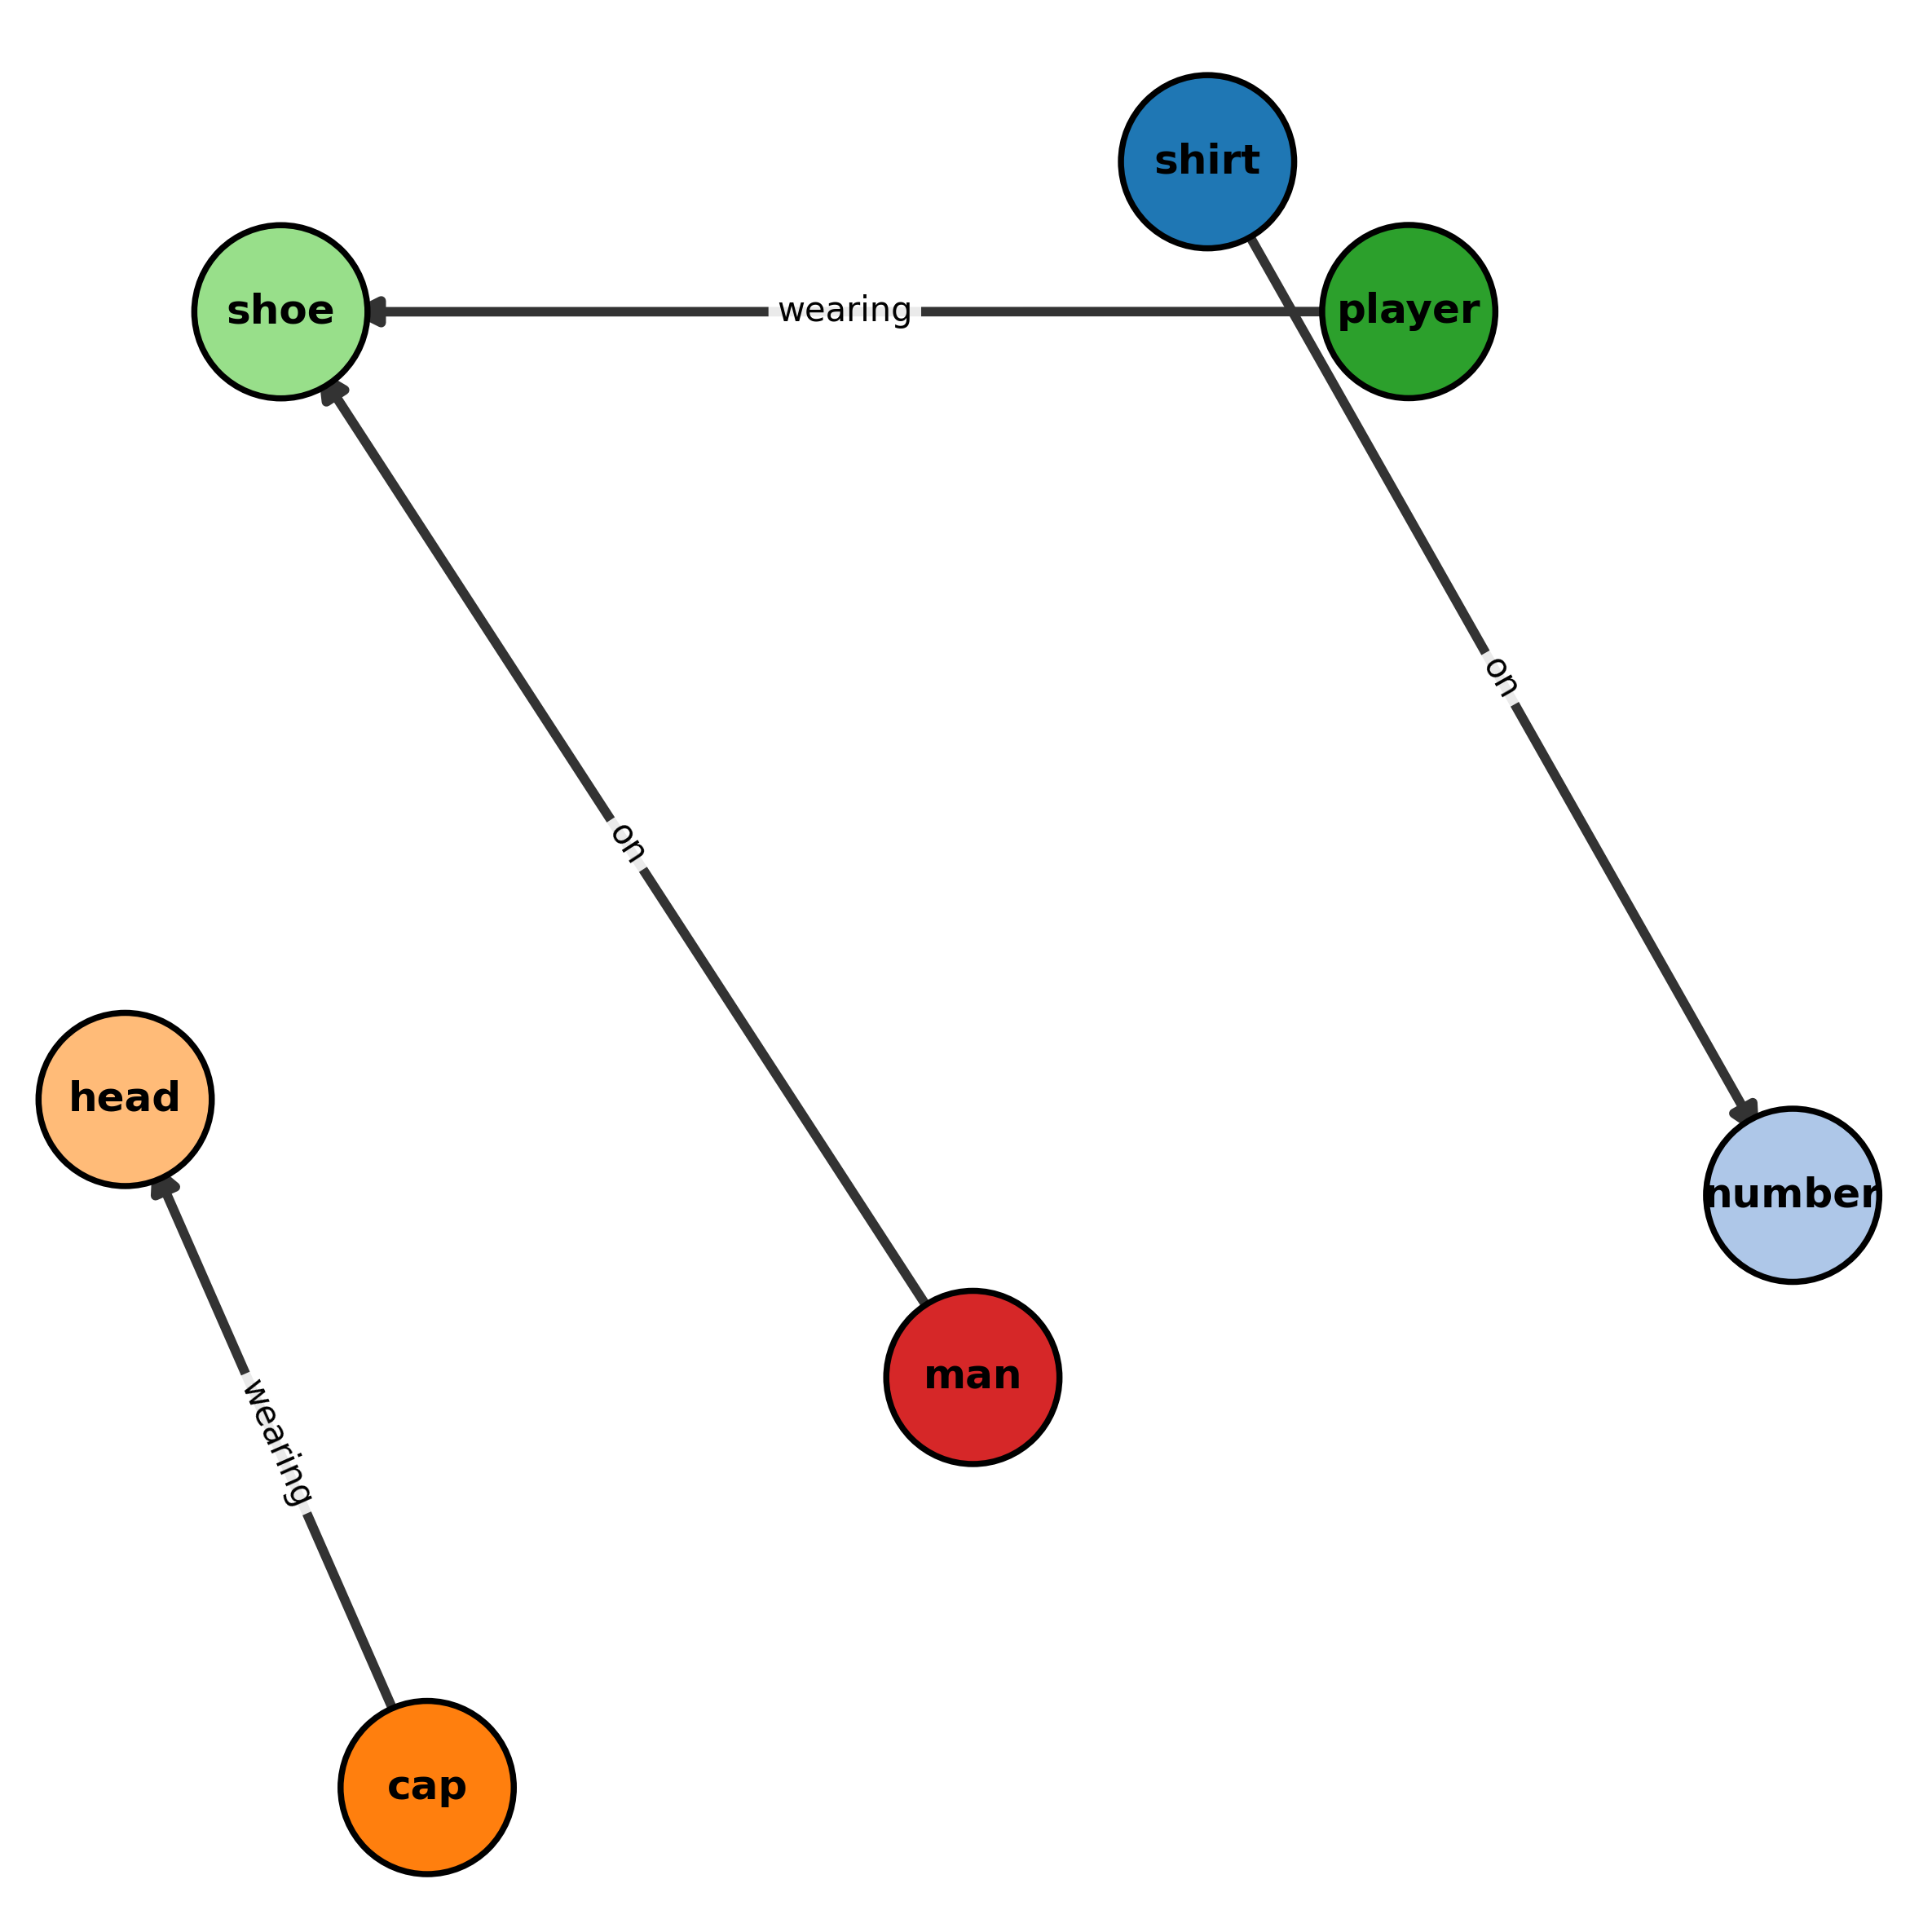

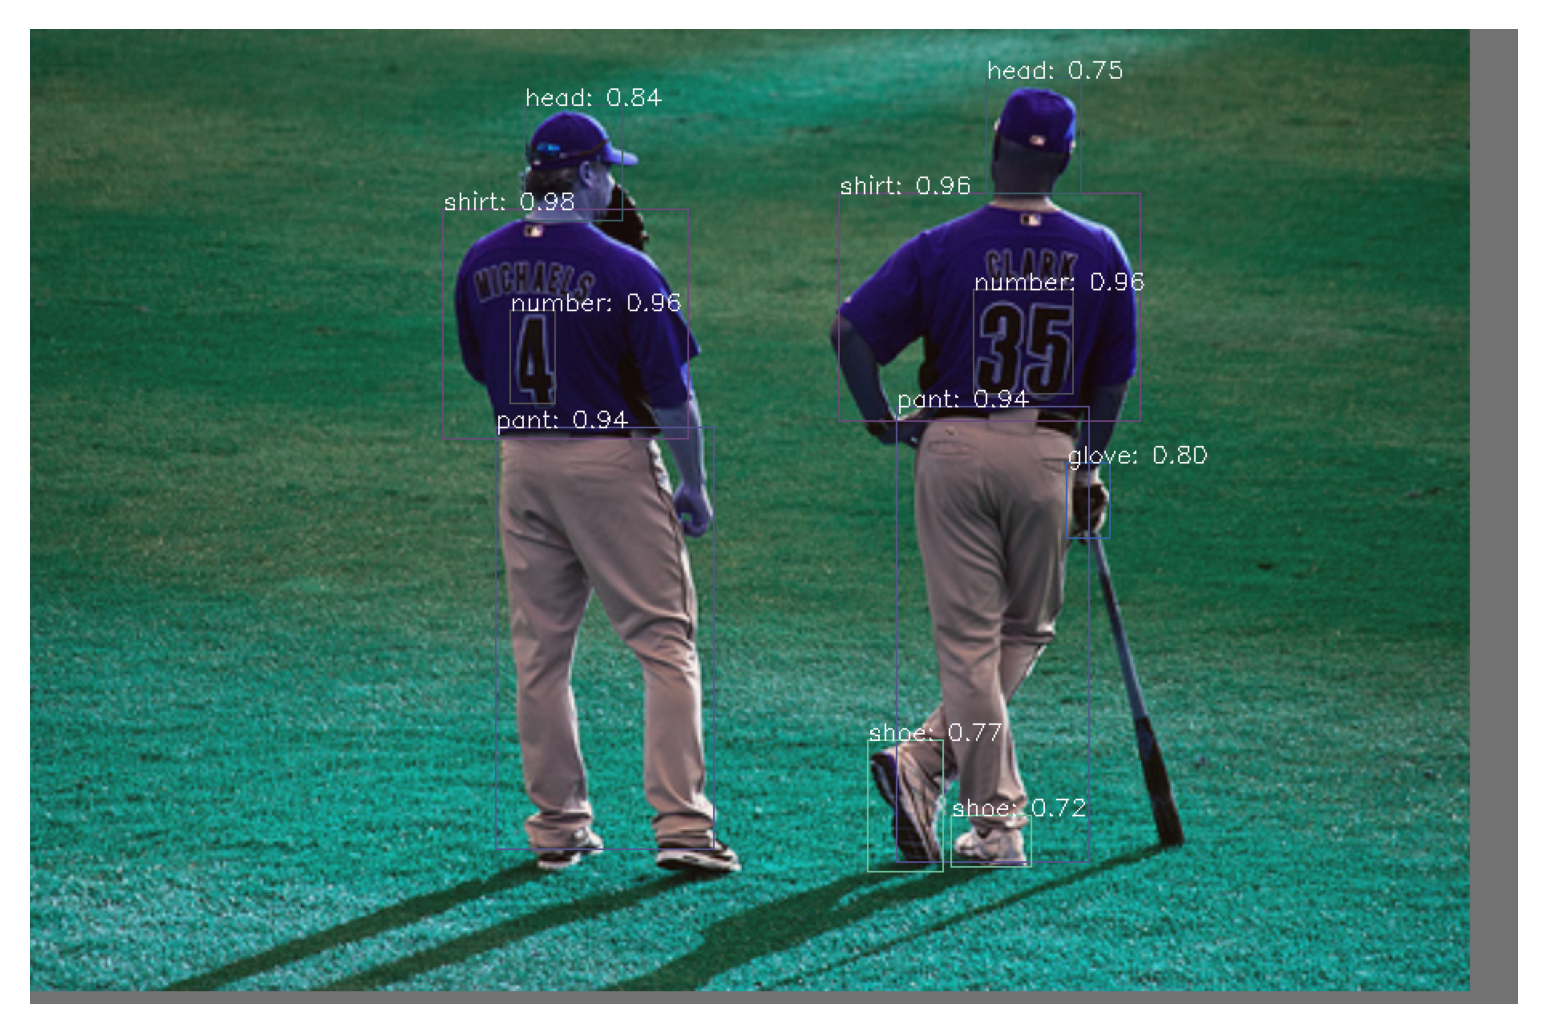

In [16]:
from IPython.display import Image, display
display(Image("graph.png"))
display(Image("output.png"))

## Trick
here is a tricky part.if you run this on colab you might get error about wrong version of numpy or scipy even if in installing you set the right version for this problem you should run this cell to reinstall them


In [7]:
!pip uninstall scipy
!pip install scipy==1.15.1
!pip uninstall numpy
!pip install numpy==1.24.1


Found existing installation: scipy 1.15.1
Uninstalling scipy-1.15.1:
  Would remove:
    /usr/local/lib/python3.11/site-packages/scipy-1.15.1.dist-info/*
    /usr/local/lib/python3.11/site-packages/scipy.libs/libgfortran-040039e1-0352e75f.so.5.0.0
    /usr/local/lib/python3.11/site-packages/scipy.libs/libgfortran-040039e1.so.5.0.0
    /usr/local/lib/python3.11/site-packages/scipy.libs/libquadmath-96973f99-934c22de.so.0.0.0
    /usr/local/lib/python3.11/site-packages/scipy.libs/libquadmath-96973f99.so.0.0.0
    /usr/local/lib/python3.11/site-packages/scipy.libs/libscipy_openblas-68440149.so
    /usr/local/lib/python3.11/site-packages/scipy/*
Proceed (Y/n)? y
  Successfully uninstalled scipy-1.15.1
DEPRECATION: Loading egg at /usr/local/lib/python3.11/site-packages/pycocotools-2.0-py3.11-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/1